# 03 — Conflict Detection

Apply FAA separation standards to detect horizontal and vertical separation violations across all aircraft pairs in each snapshot.

**FAA Standards Applied (7110.65):**
- Horizontal: < 3 NM (terminal) / < 5 NM (en route)
- Vertical: < 1,000 ft

## 1. Load & Reconstruct States

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from airspace import (AircraftState, detect_conflicts, conflicts_to_df,
                       conflict_risk_score, closing_speed_kts,
                       FAA_HORIZONTAL_SEP_NM, FAA_VERTICAL_SEP_FT)

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/raw_states.csv", parse_dates=["time_utc"])
print(f"Loaded {len(df)} state vectors across {df['time'].nunique()} snapshots")

Loaded 310 state vectors across 6 snapshots


In [2]:
def row_to_state(row) -> AircraftState:
    return AircraftState(
        icao24=row["icao24"], callsign=row["callsign"],
        time=row["time"], lat=row["lat"], lon=row["lon"],
        altitude_ft=row["altitude_ft"], velocity_kts=row["velocity_kts"],
        heading_deg=row["heading_deg"], on_ground=bool(row["on_ground"]),
    )

# Group by snapshot timestamp, reconstruct AircraftState objects
snapshots = {
    t: [row_to_state(r) for _, r in grp.iterrows()]
    for t, grp in df.groupby("time")
}
print(f"Reconstructed {len(snapshots)} snapshots")
for t, states in snapshots.items():
    print(f"  t={t}  — {len(states)} aircraft")

Reconstructed 6 snapshots
  t=1773283197.0  — 52 aircraft
  t=1773283200.0  — 53 aircraft
  t=1773283222.0  — 52 aircraft
  t=1773283225.0  — 52 aircraft
  t=1773283236.0  — 52 aircraft
  t=1773283250.0  — 49 aircraft


## 2. Run Pairwise Separation Checks

In [3]:
all_conflicts = []

for timestamp, states in snapshots.items():
    conflicts = detect_conflicts(
        states,
        horizontal_min_nm=FAA_HORIZONTAL_SEP_NM,
        vertical_min_ft=FAA_VERTICAL_SEP_FT
    )
    all_conflicts.extend(conflicts)

cdf = conflicts_to_df(all_conflicts)
print(f"Total conflict events detected: {len(cdf)}")
if len(cdf) > 0:
    print("\nSeverity breakdown:")
    print(cdf["severity"].value_counts())
cdf.head(10)

Total conflict events detected: 42

Severity breakdown:
severity
ADVISORY    25
WARNING     17
Name: count, dtype: int64


,time,icao_a,icao_b,callsign_a,callsign_b,horizontal_dist_nm,vertical_dist_ft,severity,lat_midpoint,lon_midpoint
0,1.773283e+09,adda24,acee50,AAL1456,AAL1367,1.749,350.0,WARNING,32.80345,-97.04090
1,1.773283e+09,a8b926,a34209,NKS1496,AAL2598,2.372,175.0,ADVISORY,32.87405,-97.00930
2,1.773283e+09,a34209,a87c12,AAL2598,FFT4690,1.476,25.0,WARNING,32.86280,-97.04065
3,1.773283e+09,a886bf,acee50,AAL3302,AAL1367,2.966,775.0,ADVISORY,32.77355,-97.04105
4,1.773283e+09,adda24,acee50,AAL1456,AAL1367,1.757,325.0,WARNING,32.80570,-97.04085
5,1.773283e+09,a8b926,a34209,NKS1496,AAL2598,2.168,100.0,ADVISORY,32.87665,-97.00930
6,1.773283e+09,a8b926,ac267c,NKS1496,UNKNOWN,2.967,150.0,ADVISORY,32.88995,-97.02160
7,1.773283e+09,a34209,a87c12,AAL2598,FFT4690,1.444,25.0,WARNING,32.86625,-97.04060
8,1.773283e+09,a34209,ac267c,AAL2598,UNKNOWN,2.022,250.0,ADVISORY,32.87890,-97.03860
9,1.773283e+09,a87c12,ac267c,FFT4690,UNKNOWN,1.532,275.0,WARNING,32.87955,-97.05290


## 3. Risk Scoring

Assign each conflict a composite risk score [0-100] incorporating separation margin, severity, and closing speed.

In [4]:
if len(cdf) > 0:
    # Rebuild state lookups for closing speed calculation
    state_lookup = {s.icao24: s for states in snapshots.values() for s in states}

    risk_scores = []
    for _, row in cdf.iterrows():
        sa = state_lookup.get(row["icao_a"])
        sb = state_lookup.get(row["icao_b"])
        closing = closing_speed_kts(sa, sb) if (sa and sb) else None
        from airspace import ConflictEvent
        evt = ConflictEvent(**row.to_dict())
        risk_scores.append(conflict_risk_score(evt, closing))

    cdf["risk_score"]    = risk_scores
    cdf["closing_speed"] = [
        closing_speed_kts(state_lookup.get(r["icao_a"]),
                          state_lookup.get(r["icao_b"]))
        if (state_lookup.get(r["icao_a"]) and state_lookup.get(r["icao_b"])) else None
        for _, r in cdf.iterrows()
    ]

    print("Top 10 highest-risk conflicts:")
    print(cdf.nlargest(10, "risk_score")[
        ["callsign_a","callsign_b","horizontal_dist_nm",
         "vertical_dist_ft","severity","risk_score"]
    ])

Top 10 highest-risk conflicts:
   callsign_a callsign_b  horizontal_dist_nm  vertical_dist_ft severity  \
7     AAL2598    FFT4690               1.444              25.0  WARNING   
27    AAL2598    FFT4690               1.456              25.0  WARNING   
2     AAL2598    FFT4690               1.476              25.0  WARNING   
14    NKS1496    AAL2598               1.668             100.0  WARNING   
23    NKS1496    AAL2598               1.668             100.0  WARNING   
33    NKS1496    AAL2598               1.668             100.0  WARNING   
36    AAL2598    FFT4690               1.525              50.0  WARNING   
17    AAL2598    FFT4690               1.481             125.0  WARNING   
40    AAL2987    AAL2634               1.470             300.0  WARNING   
9     FFT4690    UNKNOWN               1.532             275.0  WARNING   

    risk_score  
7        55.10  
27       54.98  
2        54.78  
14       54.40  
23       54.40  
33       54.40  
36       53.79  
17     

## 4. Visualize Conflict Distribution

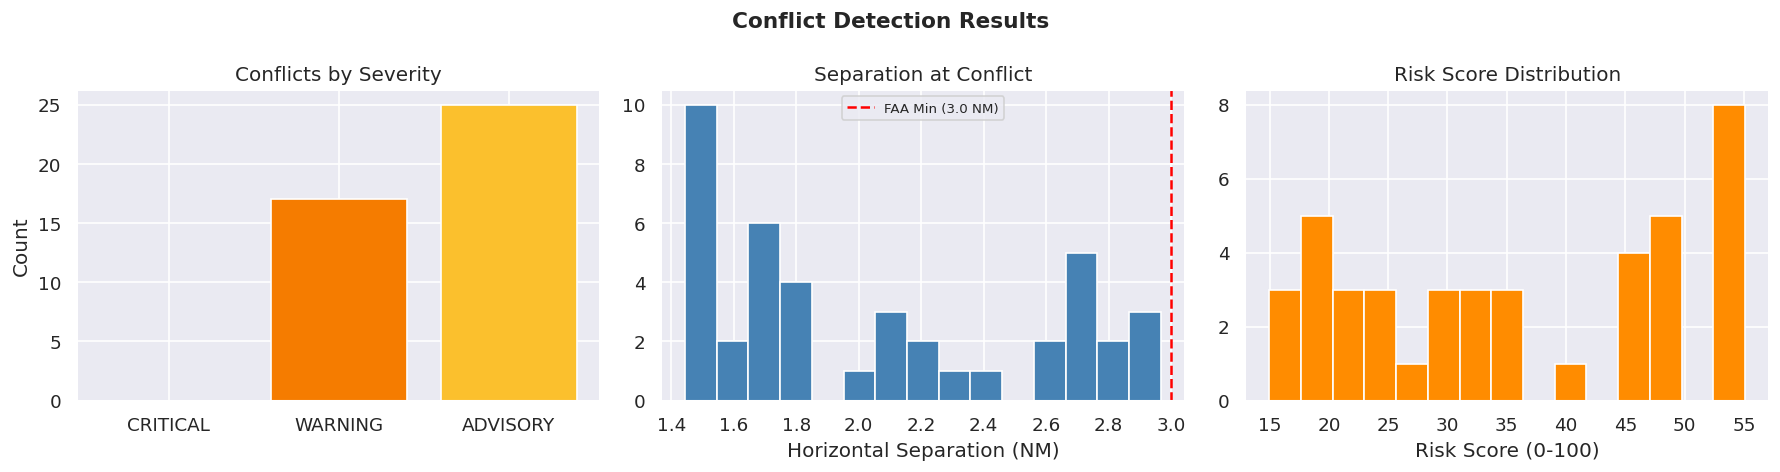

In [5]:
if len(cdf) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Severity counts
    sev_order = ["CRITICAL","WARNING","ADVISORY"]
    sev_colors = {"CRITICAL":"#d32f2f","WARNING":"#f57c00","ADVISORY":"#fbc02d"}
    sev_counts = cdf["severity"].value_counts().reindex(sev_order, fill_value=0)
    axes[0].bar(sev_counts.index,
                sev_counts.values,
                color=[sev_colors[s] for s in sev_counts.index],
                edgecolor="white")
    axes[0].set_title("Conflicts by Severity")
    axes[0].set_ylabel("Count")

    # Horizontal separation distribution
    axes[1].hist(cdf["horizontal_dist_nm"], bins=15, color="steelblue", edgecolor="white")
    axes[1].axvline(FAA_HORIZONTAL_SEP_NM, color="red", linestyle="--",
                    label=f"FAA Min ({FAA_HORIZONTAL_SEP_NM} NM)")
    axes[1].set_xlabel("Horizontal Separation (NM)")
    axes[1].set_title("Separation at Conflict")
    axes[1].legend(fontsize=8)

    # Risk score distribution
    axes[2].hist(cdf["risk_score"], bins=15, color="darkorange", edgecolor="white")
    axes[2].set_xlabel("Risk Score (0-100)")
    axes[2].set_title("Risk Score Distribution")

    plt.suptitle("Conflict Detection Results", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../outputs/03_conflicts.png", bbox_inches="tight")
    plt.show()
else:
    print("No conflicts detected in this dataset. Try increasing N_SNAPSHOTS in notebook 01.")

## 5. Save Conflict Data

In [6]:
os.makedirs("../data", exist_ok=True)
if len(cdf) > 0:
    cdf.to_csv("../data/conflicts.csv", index=False)
    print(f"Saved {len(cdf)} conflict events -> ../data/conflicts.csv")
else:
    # Write empty file so downstream notebooks don't break
    cdf.to_csv("../data/conflicts.csv", index=False)
    print("No conflicts to save — empty CSV written.")

Saved 42 conflict events -> ../data/conflicts.csv
